![alt text](image.png)

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)

In [8]:
path = "../../data/raw/"
dfs = {}

# read all dataframes and keep them in dfs
for parquet in os.listdir(path):  # List all files in the directory
    if parquet.endswith(".parquet"):
        name = parquet.split(".parquet")[0]  # Get name without extension
        dfs[name] = pd.read_parquet(os.path.join(path, parquet))  # Use os.path.join for paths
        print(f"Loaded {name} with shape {dfs[name].shape}")

Loaded 01_DiatomInventories_GTstudentproject_B with shape (1643872, 8)
Loaded 02_InfoSites_GTstudentproject_B with shape (8404, 11)
Loaded 03_IBD_GTstudentproject_test with shape (5063, 2)
Loaded 03_IBD_GTstudentproject_train with shape (43783, 4)
Loaded 04_PressureStatus_GTstudentproject_B with shape (49231, 30)
Loaded 05_EnvParamMeans_GTstudentproject_B with shape (3763903, 8)
Loaded 06_ListEnvParam_GNNprojectGT_B with shape (192, 14)
Loaded 07_TaxaCode_GTstudentproject_B with shape (2292, 2)


In [9]:
df1 = dfs[list(dfs.keys())[0]] 

se nota con el numero de unicos que el primary key para voltear es SamplingOperations_code  

In [10]:
df1.nunique()

TaxonName                            2292
TaxonCode                            2292
SamplingOperations_code             49231
CodeSite_SamplingOperations          8404
Date_SamplingOperation               2237
Abundance_nbcell                      408
TotalAbundance_SamplingOperation      188
Abundance_pm                        16667
dtype: int64

a ver mi teoria loca es que el ibd es calculado solo con taxones así:

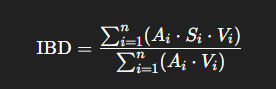

y que gracias a el super completo y coomprensivo eda de Heri se puede pensar así 

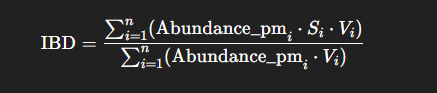


y que la regresión nos dará los valores de los demas 

In [11]:
# 1) columnas que QUIERES mantener en la llave (todas menos: TaxonName y Abundance_nbcell;
#    y quitamos TaxonCode/Abundance_pm porque se usan para columnas/valores)
cols_key = [c for c in df1.columns 
            if c not in ['TaxonName', 'Abundance_nbcell', 'TaxonCode', 'Abundance_pm']]

# 2) tabla pivote:
#    - index = todas las columnas que quieres conservar (parte del key)
#    - columns = códigos de taxón
#    - values = Abundance_pm
#    - aggfunc='sum' por si hay duplicados del mismo taxón en la misma muestra
wide = (
    df1.pivot_table(index=cols_key,
                   columns='TaxonCode',
                   values='Abundance_pm',
                   aggfunc='sum')
      .reset_index()
)

# opcional: quitar el nombre del eje de columnas
wide.columns.name = None


Ya tenemos una tabla ancha de todos los taxones y ahora los casaremos con sites primero que nada 

In [12]:
sites = dfs[list(dfs.keys())[1]]

In [13]:
taxones = pd.merge(wide, sites, on='CodeSite_SamplingOperations',how = 'left')

Ahora con la info de pressure

In [14]:
pressure = dfs[list(dfs.keys())[4]]

In [18]:
taxones_pressure = pd.merge(taxones, pressure, on=['SamplingOperations_code', 'CodeSite_SamplingOperations','Date_SamplingOperation'],how = 'inner')

Ahora con el de train y crear el df a parte de los que serán la prediccion 

In [20]:
train =  dfs[list(dfs.keys())[3]]

In [27]:
taxones_pressure_train = pd.merge(taxones_pressure,train, on = 'SamplingOperations_code', how= 'inner')
len(taxones_pressure_train)

43783

In [30]:
taxones_pressure_predict = taxones_pressure[
    ~taxones_pressure['SamplingOperations_code'].isin(train['SamplingOperations_code'])
].copy()
len(taxones_pressure_predict)

5658

In [29]:
len(taxones_pressure_train)+len(taxones_pressure_predict)

49441

In [35]:
taxones_pressure_train.to_parquet("../../data/processed/taxones_pressure.parquet", index=False)
taxones_pressure_predict.to_parquet("../../data/processed/taxones_pressure.parquet", index=False)

In [32]:
taxones_pressure_train

SamplingOperations_code CodeSite_SamplingOperations  \
0          S02000008_20170703                   S02000008   
1          S02000008_20200708                   S02000008   
2          S02000010_20070906                   S02000010   
3          S02000010_20090721                   S02000010   
4          S02000010_20110723                   S02000010   
...                       ...                         ...   
43778      S06999141_20160928                   S06999141   
43779      S06999179_20230628                   S06999179   
43780      S06999180_20160928                   S06999180   
43781      S06999189_20160928                   S06999189   
43782      S06999189_20220920                   S06999189   

      Date_SamplingOperation  TotalAbundance_SamplingOperation  Achaa01  \
0                 2017-07-03                               405      NaN   
1                 2020-07-08                               400      NaN   
2                 2007-09-06                               400      NaN   
3                 2009-07-21                               400      NaN   
4                 2011-07-23                               398      NaN   
...                      ...                               ...      ...   
43778             2016-09-28                               403      NaN   
43779             2023-06-28                               409      NaN   
43780             2016-09-28                               404      NaN   
43781             2016-09-28                               403      NaN   
43782             2022-09-20                               406      NaN   

       Achac01  Achaf01  Achaf02  Achal01  Acham01  Achan01  Achat01  \
0          NaN      NaN      NaN      NaN      NaN      NaN      NaN   
1          NaN      NaN      NaN      NaN      NaN      NaN      NaN   
2          NaN      NaN      NaN      NaN      NaN      NaN      NaN   
3          NaN      NaN      NaN      NaN      NaN      NaN      NaN   
4          NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...   
43778      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43779      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43780      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43781      NaN      NaN  2.48139      NaN      NaN      NaN      NaN   
43782      NaN      NaN      NaN      NaN      NaN      NaN      NaN   

        Achat02  Achat03  Achba01  Achbi01  Achbi02  Achbr01  Achca01  \
0           NaN      NaN      NaN      NaN      NaN      NaN      NaN   
1           NaN      NaN      NaN      NaN      NaN      NaN      NaN   
2           NaN      NaN      NaN      NaN      NaN      NaN      NaN   
3           NaN      NaN      NaN      NaN      NaN      NaN      NaN   
4           NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...         ...      ...      ...      ...      ...      ...      ...   
43778       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43779       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43780       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43781       NaN      NaN      NaN      NaN      NaN      NaN      NaN   
43782  4.926108      NaN      NaN      NaN      NaN      NaN      NaN   

       Achca02  Achca03  Achca04  Achch01  Achcl01  Achco01  Achco02  Achco03  \
0          NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
1          NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
2          NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
3          NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
4          NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...      ...   
43778      NaN      NaN      NaN      NaN      NaN      NaN    

La ultima de environmetal aprameter means en una cosa rara 

In [ ]:
epm = dfs[list(dfs.keys())[5]]
len(epm)

Hay como varios paramtros y esttos pertencen a presiones y pueden estar asciados a una muestra la muestra puede tener varios parametros. la cosa aca es que por parametro tengo la media por 3 peridos de tiempo pero esto lit no se puede interpretar porque cada parametro se lee o interprta diferente y por eso tenemos la lista en el df 6 de los que tenemos. Si no tenemos suficiente con los otros dos df vlteo este y solo nos guiamos con la otra tabla si requerimos interpretacion. 

Also, tenemos los otros 6,000 datos podemos calcularlos litlit  y esa es al clasificacioon porqur tenemos sus cosdigos de sitio y sus taxcones solo no el ibd y demas 